In [ ]:
import pandas as pd

# Load dataset
data = pd.read_csv('/content/Student_data.csv')

# Preview the data
data.head()

,Student_ID,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,ID00001,Male,20,Engineering,83.9,4.4,2.65,9.1,8,2.78
1,ID00002,Female,24,Business,80.7,4.0,3.58,4.0,4,3.76
2,ID00003,Female,20,Mathematics,91.5,3.9,3.29,6.7,4,3.75
3,ID00004,Female,23,Engineering,73.9,8.8,3.48,4.0,6,3.69
4,ID00005,Male,21,Economics,79.8,2.2,2.66,8.7,6,2.34


In [ ]:
# Number of rows & columns
print(data.shape)

# Data types and missing values
data.info()

# Statistical summary
data.describe()

(5000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           5000 non-null   object 
 1   Gender               5000 non-null   object 
 2   Age                  5000 non-null   int64  
 3   Major                5000 non-null   object 
 4   Attendance_Pct       5000 non-null   float64
 5   Study_Hours_Per_Day  5000 non-null   float64
 6   Previous_GPA         5000 non-null   float64
 7   Sleep_Hours          5000 non-null   float64
 8   Social_Hours_Week    5000 non-null   int64  
 9   Final_CGPA           5000 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 390.8+ KB


,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.948600,83.795740,4.517840,3.093824,7.012060,8.006400,3.272224
std,2.017417,12.867904,2.568104,0.476754,1.424377,2.797771,0.507954
min,18.000000,26.200000,0.100000,1.350000,4.000000,0.000000,1.160000
25%,19.000000,75.100000,2.600000,2.760000,6.000000,6.000000,2.920000
50%,21.000000,85.050000,4.000000,3.100000,7.000000,8.000000,3.310000
75%,23.000000,94.800000,6.000000,3.430000,8.000000,10.000000,3.680000
max,24.000000,100.000000,14.000000,4.000000,10.000000,20.000000,4.000000


In [ ]:
# Count missing values per column
data.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Major,0
Attendance_Pct,0
Study_Hours_Per_Day,0
Previous_GPA,0
Sleep_Hours,0
Social_Hours_Week,0
Final_CGPA,0


In [ ]:
data = data.drop('Student_ID', axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Gender', 'Major']:
    data[col] = le.fit_transform(data[col])

In [ ]:
data.head()
data.dtypes

,0
Gender,int64
Age,int64
Major,int64
Attendance_Pct,float64
Study_Hours_Per_Day,float64
Previous_GPA,float64
Sleep_Hours,float64
Social_Hours_Week,int64
Final_CGPA,float64


In [ ]:
data.head()

,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,1,20,3,83.9,4.4,2.65,9.1,8,2.78
1,0,24,0,80.7,4.0,3.58,4.0,4,3.76
2,0,20,4,91.5,3.9,3.29,6.7,4,3.75
3,0,23,3,73.9,8.8,3.48,4.0,6,3.69
4,1,21,2,79.8,2.2,2.66,8.7,6,2.34


In [ ]:
# Save preprocessed dataset
data.to_csv('/content/university_student_preprocessed.csv', index=False)

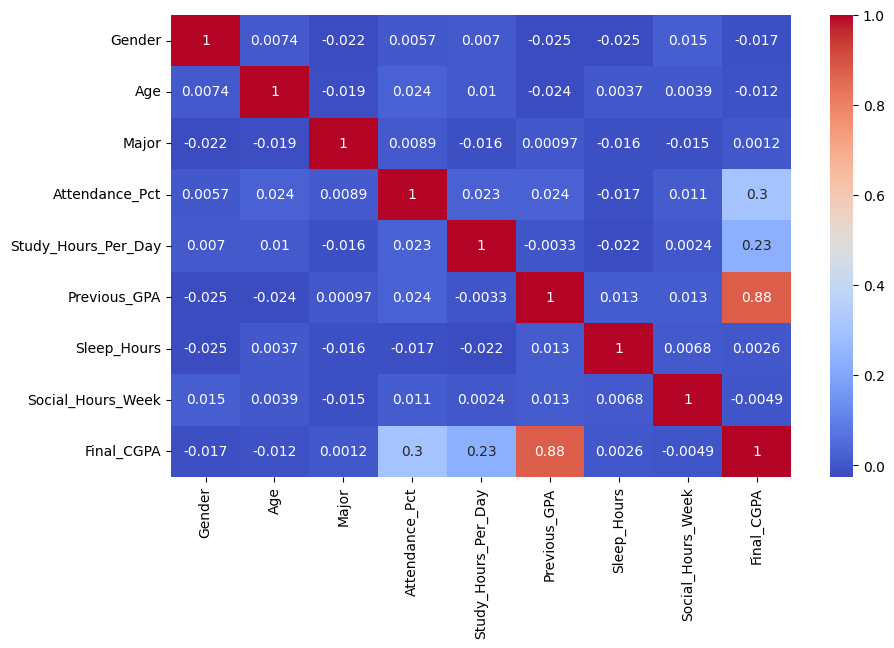

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
data.corr()['Final_CGPA'].sort_values(ascending=False)

,Final_CGPA
Final_CGPA,1.000000
Previous_GPA,0.878879
Attendance_Pct,0.302840
Study_Hours_Per_Day,0.230898
Sleep_Hours,0.002617
Major,0.001174
Social_Hours_Week,-0.004927
Age,-0.012245
Gender,-0.016582


Linear Regression --> R2 Score: 0.9091, RMSE: 0.1614
Random Forest --> R2 Score: 0.9440, RMSE: 0.1267
Gradient Boosting --> R2 Score: 0.9533, RMSE: 0.1157


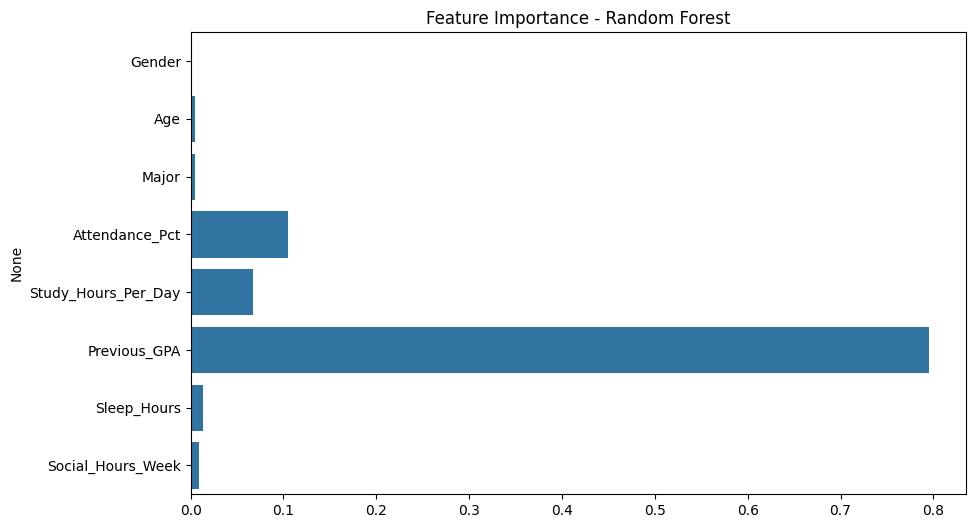

In [ ]:
# Step 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load preprocessed dataset
data = pd.read_csv('/content/university_student_preprocessed.csv')

# Step 2: Ensure target is numeric
data['Final_CGPA'] = pd.to_numeric(data['Final_CGPA'], errors='coerce')

# Check for any NaNs after conversion
assert data['Final_CGPA'].isnull().sum() == 0, "NaNs found in target!"

# Step 3: Split features and target
X = data.drop('Final_CGPA', axis=1)
y = data['Final_CGPA']

# Step 4: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

# Step 6: Train, Predict, Evaluate
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Compatible with older sklearn
    results[name] = {"R2 Score": r2, "RMSE": rmse}
    print(f"{name} --> R2 Score: {r2:.4f}, RMSE: {rmse:.4f}")

# Step 7: Feature Importance (for tree-based models)
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
new_student = pd.DataFrame({
    'Gender': [0],         # 0 or 1 depending on encoding
    'Age': [20],
    'Major': [1],          # Label encoded
    'Attendance_Pct': [90],
    'Study_Hours_Per_Day': [3],
    'Previous_GPA': [3.5],
    'Sleep_Hours': [7],
    'Social_Hours_Week': [5]
})

predicted_cgpa = rf_model.predict(new_student)
print("Predicted Final CGPA:", predicted_cgpa[0])

Predicted Final CGPA: 3.720000000000001


In [ ]:
# Step 0: Install Gradio
!pip install gradio -q

# Step 1: Import Libraries
import gradio as gr
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Step 2: Load dataset
data = pd.read_csv('/content/university_student_preprocessed.csv')

# Ensure target is numeric
data['Final_CGPA'] = pd.to_numeric(data['Final_CGPA'], errors='coerce')

# Step 3: Define mappings (VERY IMPORTANT)
gender_map = {'Male': 0, 'Female': 1}
major_map = {
    'Engineering': 0,
    'Business': 1,
    'Arts': 2,
    'Science': 3
}

# Step 4: Split data
X = data.drop('Final_CGPA', axis=1)
y = data['Final_CGPA']

# Train model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

# Step 5: Prediction Function
def predict_cgpa(Gender, Age, Major, Attendance_Pct, Study_Hours_Per_Day,
                 Previous_GPA, Sleep_Hours, Social_Hours_Week):

    # Convert string inputs → numeric
    gender_val = gender_map[Gender]
    major_val = major_map[Major]

    input_df = pd.DataFrame({
        'Gender':[gender_val],
        'Age':[Age],
        'Major':[major_val],
        'Attendance_Pct':[Attendance_Pct],
        'Study_Hours_Per_Day':[Study_Hours_Per_Day],
        'Previous_GPA':[Previous_GPA],
        'Sleep_Hours':[Sleep_Hours],
        'Social_Hours_Week':[Social_Hours_Week]
    })

    return round(model.predict(input_df)[0], 2)

# Step 6: UI (String inputs)
inputs = [
    gr.Dropdown(['Male', 'Female'], label="Gender"),
    gr.Number(label="Age"),
    gr.Dropdown(['Engineering', 'Business', 'Arts', 'Science'], label="Major"),
    gr.Slider(0, 100, label="Attendance (%)"),
    gr.Slider(0, 12, label="Study Hours Per Day"),
    gr.Number(label="Previous GPA"),
    gr.Slider(0, 12, label="Sleep Hours"),
    gr.Slider(0, 40, label="Social Hours per Week")
]

output = gr.Number(label="Predicted Final CGPA")

# Step 7: Launch App
interface = gr.Interface(
    fn=predict_cgpa,
    inputs=inputs,
    outputs=output,
    title="University Student CGPA Predictor",
    description="Enter student details to predict final CGPA."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4eb33e5f0694af3bd9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
